# Proyecto: Clasificación Multiclase Bayesiana y Comparación con Métodos Frecuentistas

## Objetivo general

El objetivo de este proyecto es construir y comparar modelos de clasificación multiclase utilizando enfoques:

- bayesianos,
- frecuentistas,
- y métodos de optimización modernos.

Los estudiantes deberán implementar modelos multinomiales en NumPyro y compararlos contra modelos frecuentistas entrenados mediante descenso por gradiente utilizando PyTorch.

---

# Notación

- $y_i \in \{1,\dots,K\}$ representa la clase observada.
- $K$ es el número de clases.
- $x_i$ es el vector de covariables.
- $\beta$ representa los coeficientes del modelo.
- $\tau$ es el hyperparámetro de regularización.
- $X$ representa la matriz de diseño.
- $n$ es el número de observaciones.
- $p$ es el número de covariables.

---

# 1. Clasificación multiclase

El problema consiste en clasificar observaciones en múltiples categorías:

$$
y_i \in \{1,\dots,K\}
$$

Cada observación posee un predictor lineal asociado a cada clase:

$$
\eta_{ik} = x_i^T\beta_k
$$

donde:

- $\beta_k$ representa el vector de coeficientes para la clase $k$.

---

# 2. Modelo Multinomial Bayesiano

El modelo bayesiano utiliza:

$$
y_i
\sim
\text{Categorical}(\pi_i)
$$

donde las probabilidades de clase se obtienen mediante la función softmax:

$$
\pi_{ik}
=
\frac{\exp(x_i^T\beta_k)}
{\sum_{j=1}^{K}\exp(x_i^T\beta_j)}
$$

Esto garantiza:

$$
\sum_{k=1}^{K}\pi_{ik}=1
$$

---

# 3. Priors Bayesianos

Los coeficientes utilizan priors Gaussianos:

$$
\beta_{kj}
\sim
\mathcal{N}(0,\tau^2)
$$

con hyperprior:

$$
\tau
\sim
\text{HalfNormal}(10)
$$

El hyperparámetro $\tau$ controla el nivel de regularización global sobre los coeficientes.

---

# 4. Inferencia Bayesiana

El objetivo es aproximar la distribución posterior:

$$
p(\beta,\tau \mid X,y)
$$

utilizando:

- Markov Chain Monte Carlo (MCMC),
- Hamiltonian Monte Carlo (HMC),
- No-U-Turn Sampler (NUTS).

El resultado final son muestras posteriores de los parámetros y probabilidades predictivas.

---

# 5. Modelo Frecuentista Multinomial

Como comparación se implementará un modelo frecuentista utilizando PyTorch.

El modelo consiste en una capa lineal:

$$
f(x)=Wx+b
$$

seguida por la función softmax:

$$
\hat p_k(x)
=
\frac{\exp(f_k(x))}
{\sum_{j=1}^{K}\exp(f_j(x))}
$$

---

# 6. Optimización mediante descenso por gradiente

El modelo frecuentista será entrenado mediante:

- Stochastic Gradient Descent (SGD),
- minibatches,
- backpropagation.

La función de pérdida utilizada será:

$$
\mathcal{L}
=
-\sum_{i=1}^{n}
\sum_{k=1}^{K}
y_{ik}\log(\hat p_{ik})
$$

correspondiente a la Cross-Entropy Loss.

---

# 7. Early Stopping

Durante el entrenamiento frecuentista se utilizará early stopping.

La idea principal consiste en:

- monitorear la pérdida de validación,
- detener entrenamiento cuando ya no exista mejora significativa.

Esto ayuda a:

- evitar sobreajuste,
- mejorar generalización,
- reducir tiempo computacional.

---

# 8. Validación Cruzada

La evaluación de modelos se realizará mediante validación cruzada.

En cada fold:

1. se ajusta el modelo,
2. se generan predicciones,
3. se evalúa desempeño fuera de muestra.

---

# 9. Métricas de evaluación

Las métricas principales serán:

---

## Negative Log-Likelihood (NLL)

$$
\text{NLL}
=
-\log p(y_{\text{valid}} \mid X_{\text{valid}})
$$

Interpretación:

- menor NLL:
  - mejor calibración probabilística,
  - mejor desempeño predictivo.

---

## Accuracy

La accuracy mide la proporción de clasificaciones correctas:

$$
\text{Accuracy}
=
\frac{1}{n}
\sum_{i=1}^{n}
\mathbb{I}(y_i=\hat y_i)
$$

---

# 10. Comparación Bayesiano vs Frecuentista

Uno de los objetivos centrales será comparar ambos enfoques.

---

## Enfoque Bayesiano

Ventajas:

- cuantificación explícita de incertidumbre,
- distribuciones posteriores,
- regularización probabilística,
- interpretación inferencial.

Desventajas:

- mayor costo computacional,
- entrenamiento más lento.

---

## Enfoque Frecuentista

Ventajas:

- entrenamiento rápido,
- escalabilidad,
- implementación eficiente en GPU.

Desventajas:

- menor cuantificación de incertidumbre,
- parámetros puntuales.

---

# 11. Visualización y análisis posterior

Los estudiantes deberán analizar:

- distribuciones posteriores de coeficientes,
- curvas de entrenamiento,
- curvas de validación,
- convergencia MCMC,
- incertidumbre predictiva,
- estabilidad del modelo.

---

# 12. Objetivos específicos del proyecto

Los estudiantes deberán:

1. Seleccionar un dataset multiclase real.
2. Realizar limpieza y preprocesamiento.
3. Implementar el modelo multinomial bayesiano.
4. Implementar el modelo frecuentista en PyTorch.
5. Ajustar modelos y analizar convergencia.
6. Comparar desempeño predictivo.
7. Analizar incertidumbre y regularización.
8. Interpretar resultados estadísticos.
9. Elaborar conclusiones comparativas.

---

# 13. Entregables sugeridos

El proyecto deberá incluir:

- notebook reproducible,
- explicación teórica,
- análisis exploratorio,
- implementación de modelos,
- métricas de evaluación,
- visualizaciones posteriores,
- curvas de entrenamiento,
- interpretación estadística,
- conclusiones.

In [27]:
import jax
import jax.numpy as jnp
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, log_likelihood
import jax.random as random
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split, ParameterSampler, KFold
from scipy.stats import distributions as scdist
import numpyro
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score
from tqdm import tqdm
import copy

numpyro.set_host_device_count(3)
plt.style.use("ggplot")

In [28]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# **Conjunto de datos**

En el proyecto pueden usar datos simulados para ilustrar, pero también utilicen datos reales para resolver un problema de aprendizaje no supervisado. Realicen el debido preprocesamiento de datos que han aprendido en sus demás cursos antes de ajustar los modelos: escaladores, métodos de reducción de dimensión con PCA, entre otros.

In [29]:
n = 1000
p = 4
K = 3

seed = 18081997

np.random.seed(seed)

rng_key = random.PRNGKey(seed)

# =====================================================
# Features
# =====================================================

X = np.random.randn(n, p)

# intercept
X = np.hstack((np.ones((n, 1)), X))

# =====================================================
# True coefficients
# =====================================================

beta_true = np.array([
    [0.0, 0.0, 0.0],   # intercepts
    [3.0, 0.0, -3.0],
    [0.0, 3.0, -3.0],
    [2.0, -2.0, 0.0],
    [-2.0, 2.0, 0.0]
])

# =====================================================
# Probabilities
# =====================================================

logits = X @ beta_true

mu = jax.nn.softmax(
    logits,
    axis=-1
)

# =====================================================
# Sample labels
# =====================================================

y = dist.Categorical(
    probs=mu
).sample(rng_key)

# =====================================================
# JAX arrays
# =====================================================

X = jnp.array(X)

y = jnp.array(y)

# =====================================================
# Train / validation
# =====================================================

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=seed
)

In [3]:
def multinomial_regression(X, y=None, K=3):

    n, p = X.shape

    tau = numpyro.sample("tau", dist.HalfNormal(10.0))

    beta = numpyro.sample(
            "beta",
            dist.Normal(0, tau).expand([K, p]).to_event(2)
        )

    logits = jnp.dot(X, beta.T)

    with numpyro.plate("data", n):

        numpyro.sample(
                "y",
                dist.Categorical(logits=logits),
                obs=y
            )

In [4]:
burn_in = 2000
num_samples = 2000
num_chains = 3
chain_method = "parallel"

seed = 18081997

In [5]:
def cv_metrics_model(model, X, y, folds=5, seed=1, K=3):

    kf = KFold(n_splits=folds, shuffle=True, random_state=seed)

    fold_nll = []
    fold_acc = []

    progress_bar = tqdm(total=folds, desc="Cross Validation")

    for fold, (train_indx, valid_indx) in enumerate(kf.split(X)):

        X_train, X_valid = X[train_indx], X[valid_indx]
        y_train, y_valid = y[train_indx], y[valid_indx]

        rng_key = random.PRNGKey(seed + fold)

        kernel = NUTS(model)

        mcmc = MCMC(kernel,
                        num_samples=num_samples,
                        num_chains=num_chains,
                        num_warmup=burn_in,
                        chain_method=chain_method,
                        progress_bar=False)

        mcmc.run(rng_key, X_train, y_train, K)

        posterior_samples = mcmc.get_samples()

        beta = posterior_samples["beta"]


        nll = -log_likelihood(model, posterior_samples, X_valid, y_valid, K)["y"].mean().item()

        logits = jnp.einsum(
           "np,skp->snk",
            X_valid,
            beta
            )

        probs = jax.nn.softmax(logits, axis=-1)

            # predicción por muestra MCMC
        y_pred = jnp.argmax(probs, axis=-1)

            # accuracy por muestra
        acc_samples = (
                y_pred == y_valid[None, :]
            ).mean(axis=1)

            # promedio posterior
        acc = acc_samples.mean().item()


        fold_nll.append(nll)
        fold_acc.append(acc)


        progress_bar.update(1)
        progress_bar.set_postfix({
            "fold": fold,
            "nll": f"{nll:.4f}",
            "acc": f"{acc:.4f}"
            })


    progress_bar.close()

    return fold_nll, fold_acc

In [6]:
nnl, acc = cv_metrics_model(multinomial_regression, X_train, y_train, K=3)

Cross Validation: 100%|██████████| 5/5 [01:01<00:00, 12.37s/it, fold=4, nll=0.2741, acc=0.8935]


In [7]:
print("mean nll:", np.mean(nnl))
print("std nll:", np.std(nnl))
print("------------------------------")

print("mean acc:", np.mean(acc))
print("std acc:", np.std(acc))

mean nll: 0.2587867110967636
std nll: 0.019331876326235793
------------------------------
mean acc: 0.8910159468650818
std acc: 0.011958487431344549


In [74]:
class MultinomialRegression(torch.nn.Module):

    def __init__(self, input_dim, lr=1e-3, batch_size=32, K=2, device=None, bias=True):

        super().__init__()

        self.device = device if device is not None else torch.device(
            "cuda" if torch.cuda.is_available() else "cpu"
        )

        self.K = K
        self.batch_size = batch_size
        self.lr = lr
        self.linear = nn.Linear(input_dim, K, bias=bias)
        self.loss_history = []
        self.val_loss_history = []

        self.to(self.device)

    def forward(self, x):

        x = x.to(self.device)


        return self.linear(x)

    def predict_proba(self, X):

        self.eval()

        with torch.no_grad():

            logits = self.forward(X)

            return torch.softmax(logits, dim=-1)

    def predict(self, X):

        return self.predict_proba(X).argmax(dim=-1)

    def accuracy(self, X, y):

        pred = self.predict(X)

        acc = (pred == y).float().mean()

        return acc.item()

    def fit(self, X, y, X_val=None, y_val=None, epochs=50, patience=5, tol=1e-4):

        X = X.to(self.device)
        y = y.to(self.device).long()

        if X_val is not None and y_val is not None:
            X_val = X_val.to(self.device)
            y_val = y_val.to(self.device).long()

        dataset = TensorDataset(X, y)
        loader =  DataLoader(dataset, batch_size=self.batch_size, shuffle=True)
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.SGD(self.parameters(), lr=self.lr)

        best_loss = float("inf")
        best_state = None
        patience_counter = 0


        pbar = tqdm(range(epochs), desc="Training", leave=True)

        for epoch in pbar:

            self.train()
            epoch_loss = 0.0

            for xb, yb in loader:

                optimizer.zero_grad()

                probs = self.forward(xb)

                loss = criterion(probs, yb)

                loss.backward()

                optimizer.step()

                epoch_loss += loss.item()

            epoch_loss = epoch_loss / len(loader)

            self.loss_history.append(epoch_loss)

            train_acc = self.accuracy(X, y)

            if X_val is not None and y_val is not None:

                self.eval()

                with torch.no_grad():

                    val_logits = self.forward(X_val)
                    val_loss = criterion(val_logits, y_val).item()

                self.val_loss_history.append(val_loss)
                val_acc = self.accuracy(X_val, y_val)

                if val_loss < best_loss -tol:

                    best_loss = val_loss
                    best_state = copy.deepcopy(self.state_dict())
                    patience_counter = 0

                else:

                    patience_counter = patience_counter + 1

                if val_loss is not None:

                   pbar.set_postfix({
                       "train_loss": f"{epoch_loss:.4f}",
                        "train_acc": f"{train_acc:.4f}",
                        "val_loss": f"{val_loss:.4f}",
                        "val_acc": f"{val_acc:.4f}"
                            })

                else:

                    pbar.set_postfix({
                       "train_loss": f"{epoch_loss:.4f}",
                        "train_acc": f"{train_acc:.4f}"
                            })

                if patience_counter >= patience:
                    pbar.set_postfix({"early_stopping": epoch})
                    break

            if best_state is not None:
                self.load_state_dict(best_state)


In [75]:
X_train = torch.Tensor(X_train)
X_valid = torch.Tensor(X_val)
y_train = torch.Tensor(y_train)
y_valid = torch.Tensor(y_val)

In [79]:
multinom_model = MultinomialRegression(p+1, K=3, bias=False)

In [80]:
multinom_model.fit(X_train, y_train, X_valid, y_valid, epochs=500, patience=5, tol=1e-4)

Training: 100%|██████████| 500/500 [00:17<00:00, 28.23it/s, train_loss=0.3752, train_acc=0.8953, val_loss=0.3595, val_acc=0.9267]


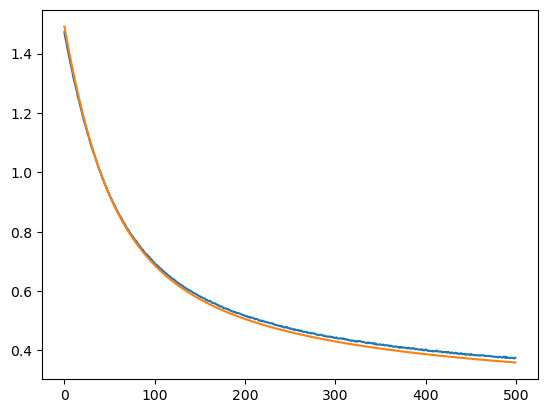

In [81]:
plt.plot(multinom_model.loss_history)
plt.plot(multinom_model.val_loss_history)
plt.show()